# NYISO Energy Demand Forecasting — Phase 1

Forecasting electricity demand for the New York Independent System Operator,
the balancing authority that keeps supply and demand matched across New York
State's grid.

**Why this problem.** A grid operator must commit generation *before* it is
needed. Commit too little and you buy emergency power at punishing prices or
shed load; commit too much and you have paid to spin turbines nobody used.
Peak demand is what sizes that decision, so a day-ahead peak forecast is one of
the load-bearing numbers in grid operations.

**Goal of Phase 1:** prove out the ML core (data → features → model → MLflow)
end-to-end with a manual script before wiring any AWS/pipeline infrastructure.
Everything here runs on a laptop, on purpose — the point is to know the model
works before adding the complexity of managed services.

### Targets

| Target | Definition | Status |
|---|---|---|
| `daily_peak_mw` | Max hourly demand per day | modelled below |
| `weekly_total_mwh` | Sum of hourly demand per week | computed and saved, **not yet modelled** |

### What "good" looks like

The bar is not a low MAE — it is **beating the persistence baseline**
("tomorrow looks like today"), which is free to compute and surprisingly hard
to beat in a highly autocorrelated series. Section 6b makes that comparison
explicit, because without it a strong-looking score may just be the model
echoing yesterday's value back.

### Data sources

- [EIA API](https://www.eia.gov/opendata/) — hourly electricity demand, NYISO (`respondent=NYIS`)
- [NOAA NCEI Climate Data Online](https://www.ncei.noaa.gov/cdo-web/webservices/v2) — daily temperature for a NYC-area station

**You will need:**
- An EIA API key → https://www.eia.gov/opendata/register.php
- An NCEI/NOAA CDO token → https://www.ncdc.noaa.gov/cdo-web/token

Both are free and arrive instantly by email. Put them in a `.env` file next to
this notebook; it is gitignored and never committed.

### Notebook map

| § | Contents |
|---|---|
| 0–1 | Setup, chart style, EIA hourly demand pull |
| 2–2b | Aggregation to targets, data-quality check, demand EDA |
| 3–4 | NOAA weather, merge, temperature response curve, feature engineering |
| 5 | Chronological train/validation split |
| 6–6b | XGBoost + MLflow, **persistence baseline comparison** |
| 7–8 | Predictions, residual diagnostics, error breakdown, feature importance |
| 9–10 | Persist processed data, limitations, next steps |

## 0. Setup

In [16]:
import os
import time
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)


In [17]:
# --- Chart style -----------------------------------------------------------
# One visual system for every figure below, so the notebook reads as a single
# document rather than a pile of defaults. Colors come from a palette validated
# for colour-vision deficiency (worst adjacent-pair separation dE 9.1 protan,
# 22.9 normal); the ordering is the safety mechanism, so use the slots in order
# rather than picking hues by taste.
%matplotlib inline

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# Categorical slots - assign in fixed order, never cycled.
C = {
    "blue":    "#2a78d6",   # slot 1
    "orange":  "#eb6834",   # slot 2
    "aqua":    "#1baf7a",   # slot 3
    "yellow":  "#eda100",   # slot 4
}
# Sequential blue ramp, light -> dark, for ordered magnitude (e.g. year).
SEQ_BLUE = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
            "#2a78d6", "#256abf", "#1c5cab", "#104281"]
# Diverging blue <-> red with a neutral gray midpoint, for signed quantities
# (correlation, error). Never a rainbow; never a hue at the midpoint.
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#104281", "#2a78d6", "#f0efec", "#e34948", "#8f2020"]
)

INK      = "#0b0b0b"   # primary text
INK_SOFT = "#52514e"   # secondary text
GRID     = "#dcdbd6"   # recessive grid
SURFACE  = "#fcfcfb"

mpl.rcParams.update({
    "figure.figsize":    (12, 5),
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   INK_SOFT,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   INK,
    "axes.titlelocation":"left",
    "axes.titlepad":     12,
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "xtick.color":       INK_SOFT,
    "ytick.color":       INK_SOFT,
    "text.color":        INK,
    "legend.frameon":    False,
    "lines.linewidth":   2.0,     # 2px lines
    "font.size":         10,
})


def tidy(ax, ylabel=None, xlabel=None):
    """Strip chartjunk: no top/right spines, recessive remaining ones."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def label_line(ax, x, y, text, color):
    """Direct-label a line at its right end.

    Two of our four categorical slots sit below 3:1 contrast on a light
    surface, which obliges visible labels rather than a colour-only legend.
    """
    ax.annotate(text, xy=(x, y), xytext=(6, 0), textcoords="offset points",
                va="center", ha="left", fontsize=9, color=color, weight="bold")


print("chart style loaded")

chart style loaded


In [18]:
# --- Config ---
# Keep secrets out of source control. Either export them before launching Jupyter:
#     export EIA_API_KEY=...   NOAA_TOKEN=...
# or put them in a .env file next to this notebook (not committed).

from pathlib import Path

def _load_dotenv(path=".env"):
    """Minimal .env loader so we don't need python-dotenv."""
    p = Path(path)
    if not p.exists():
        p = Path("..") / path
    if not p.exists():
        return
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        os.environ.setdefault(k.strip(), v.strip().strip("\'\""))

_load_dotenv()

EIA_API_KEY = os.environ.get("EIA_API_KEY", "")
NOAA_TOKEN  = os.environ.get("NOAA_TOKEN", "")

# Fail fast with a useful message instead of a confusing 403 from the API.
if not EIA_API_KEY or EIA_API_KEY.startswith("PASTE_"):
    raise RuntimeError(
        "EIA_API_KEY is not set. Get a free key at https://www.eia.gov/opendata/register.php "
        "then either `export EIA_API_KEY=...` before starting Jupyter, or add "
        "EIA_API_KEY=... to a .env file next to this notebook."
    )
if not NOAA_TOKEN or NOAA_TOKEN.startswith("PASTE_"):
    print("WARNING: NOAA_TOKEN is not set - the weather cells below will fail. "
          "Request one at https://www.ncdc.noaa.gov/cdo-web/token")

# NYISO respondent code in EIA's RTO dataset
EIA_RESPONDENT = "NYIS"

# NOAA station: LaGuardia Airport (good proxy for NYC-area temps, long history)
NOAA_STATION_ID = "GHCND:USW00014732"

START_DATE = "2019-01-01"
END_DATE   = pd.Timestamp.today().strftime("%Y-%m-%d")

print(f"Pulling data from {START_DATE} to {END_DATE}")


Pulling data from 2019-01-01 to 2026-09-02


## 1. Pull EIA hourly demand data (NYISO)

The EIA v2 API paginates in chunks (max 5000 rows per call), so we loop over date windows until we've covered the full range.


In [19]:
PAGE_SIZE = 5000  # EIA v2 max rows per request


def fetch_eia_demand(api_key, respondent, start_date, end_date, chunk_days=200):
    """
    Pull hourly demand (MWh) for a given EIA respondent (balancing authority)
    between start_date and end_date, paginating by date window and by offset
    within each window.
    """
    base_url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"
    all_rows = []

    # Half-open windows: EIA treats start/end as inclusive, so step the start
    # of the next window one day past the end of the current one.
    edges = pd.date_range(start_date, end_date, freq=f"{chunk_days}D")
    if edges[-1] < pd.Timestamp(end_date):
        edges = edges.append(pd.DatetimeIndex([pd.Timestamp(end_date)]))

    for i in range(len(edges) - 1):
        window_start = edges[i]
        # last window keeps the true end date; earlier ones stop a day short
        window_end = edges[i + 1] if i == len(edges) - 2 else edges[i + 1] - pd.Timedelta(days=1)
        ws, we = window_start.strftime("%Y-%m-%d"), window_end.strftime("%Y-%m-%d")

        offset, window_rows = 0, 0
        while True:
            params = {
                "api_key": api_key,
                "frequency": "hourly",
                "data[0]": "value",
                "facets[respondent][0]": respondent,
                "facets[type][0]": "D",  # D = Demand
                "start": ws,
                "end": we,
                "sort[0][column]": "period",
                "sort[0][direction]": "asc",
                "offset": offset,
                "length": PAGE_SIZE,
            }

            resp = requests.get(base_url, params=params, timeout=30)
            if not resp.ok:
                # EIA returns a JSON body explaining the failure (bad key, bad facet, ...)
                raise RuntimeError(
                    f"EIA request failed ({resp.status_code}) for {ws} -> {we}: {resp.text[:500]}"
                )
            payload = resp.json()

            rows = payload.get("response", {}).get("data", [])
            all_rows.extend(rows)
            window_rows += len(rows)

            if len(rows) < PAGE_SIZE:
                break
            offset += PAGE_SIZE
            time.sleep(0.3)

        print(f"  {ws} -> {we}: {window_rows} rows (total so far: {len(all_rows)})")
        time.sleep(0.3)  # be polite to the API

    df = pd.DataFrame(all_rows)
    return df


print("Fetching NYISO hourly demand from EIA...")
eia_raw = fetch_eia_demand(EIA_API_KEY, EIA_RESPONDENT, START_DATE, END_DATE)
eia_raw.head()


Fetching NYISO hourly demand from EIA...
  2019-01-01 -> 2019-07-19: 4800 rows (total so far: 4800)
  2019-07-20 -> 2020-02-04: 4800 rows (total so far: 9600)
  2020-02-05 -> 2020-08-22: 4800 rows (total so far: 14400)
  2020-08-23 -> 2021-03-10: 4800 rows (total so far: 19200)
  2021-03-11 -> 2021-09-26: 4800 rows (total so far: 24000)
  2021-09-27 -> 2022-04-14: 4799 rows (total so far: 28799)
  2022-04-15 -> 2022-10-31: 4800 rows (total so far: 33599)
  2022-11-01 -> 2023-05-19: 4800 rows (total so far: 38399)
  2023-05-20 -> 2023-12-05: 4800 rows (total so far: 43199)
  2023-12-06 -> 2024-06-22: 4800 rows (total so far: 47999)
  2024-06-23 -> 2025-01-08: 4800 rows (total so far: 52799)
  2025-01-09 -> 2025-07-27: 4800 rows (total so far: 57599)
  2025-07-28 -> 2026-02-12: 4800 rows (total so far: 62399)
  2026-02-13 -> 2026-08-31: 4800 rows (total so far: 67199)
  2026-09-01 -> 2026-09-02: 46 rows (total so far: 67245)


,period,respondent,respondent-name,type,type-name,value,value-units
0,2019-01-01T00,NYIS,New York Independent System Operator,D,Demand,19586,megawatthours
1,2019-01-01T01,NYIS,New York Independent System Operator,D,Demand,18891,megawatthours
2,2019-01-01T02,NYIS,New York Independent System Operator,D,Demand,18198,megawatthours
3,2019-01-01T03,NYIS,New York Independent System Operator,D,Demand,17423,megawatthours
4,2019-01-01T04,NYIS,New York Independent System Operator,D,Demand,16613,megawatthours


Hourly demand rows: 67244
Date range: 2019-01-01 00:00:00 to 2026-09-02 21:00:00


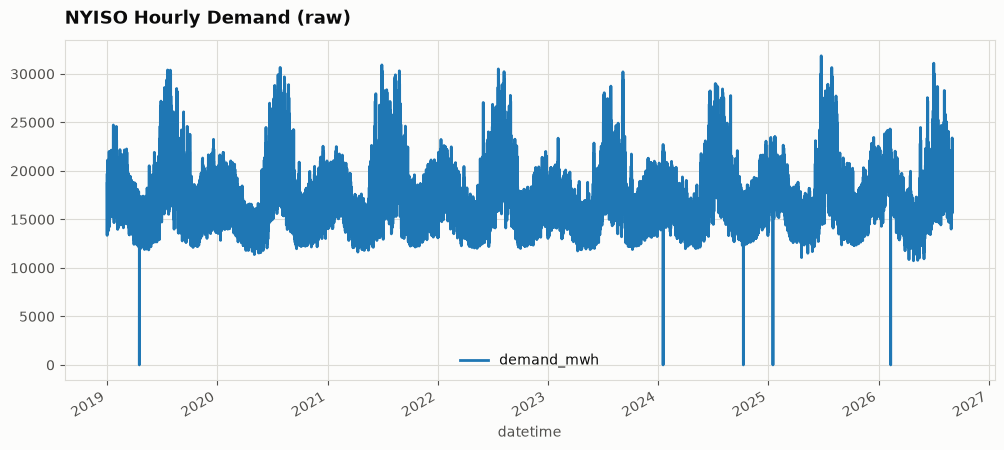

In [20]:
# Clean up EIA response into a tidy hourly demand series
demand_hourly = eia_raw[["period", "value"]].copy()
demand_hourly.columns = ["datetime", "demand_mwh"]
demand_hourly["datetime"] = pd.to_datetime(demand_hourly["datetime"])
demand_hourly["demand_mwh"] = pd.to_numeric(demand_hourly["demand_mwh"], errors="coerce")
demand_hourly = demand_hourly.dropna().drop_duplicates(subset="datetime").sort_values("datetime")
demand_hourly = demand_hourly.set_index("datetime")

print(f"Hourly demand rows: {len(demand_hourly)}")
print(f"Date range: {demand_hourly.index.min()} to {demand_hourly.index.max()}")
demand_hourly.plot(y="demand_mwh", title="NYISO Hourly Demand (raw)")
plt.show()


### Data quality check

Before trusting any of this, confirm the series is actually complete. A gap in
the hourly feed silently corrupts `daily_peak_mw` (a missing afternoon hour
means the day's true peak never enters the max) and `weekly_total_mwh` (a
missing hour is a missing few thousand MWh, not a missing row you'd notice).

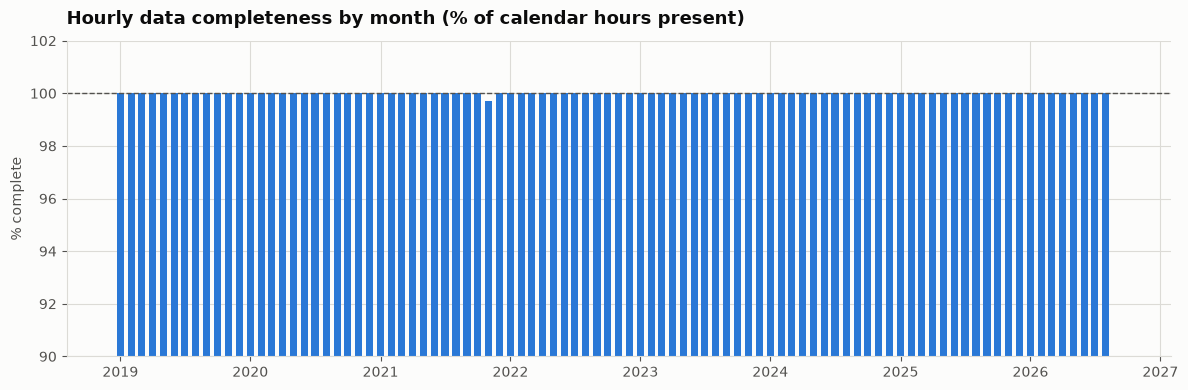

Months below 99% coverage: 0
Total missing hours: 2
Duplicate timestamps dropped earlier: 1


In [21]:
# Hourly coverage per month: observed rows vs. the number the calendar demands.
coverage = pd.DataFrame({"observed": demand_hourly.resample("MS").size()})
coverage["expected"] = coverage.index.days_in_month * 24
coverage["pct"] = 100 * coverage["observed"] / coverage["expected"]

# The current month is partial by definition - it hasn't happened yet.
complete = coverage.iloc[:-1]
short_months = complete[complete["pct"] < 99]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(coverage.index, coverage["pct"], width=20, color=C["blue"])
ax.axhline(100, color=INK_SOFT, linestyle="--", linewidth=1)
ax.set_ylim(90, 102)
ax.set_title("Hourly data completeness by month (% of calendar hours present)")
tidy(ax, ylabel="% complete")

# Direct-label the shortfalls rather than making the reader hunt for short bars.
for ts, row in short_months.iterrows():
    ax.annotate(f"{ts:%b %Y}\n{row['pct']:.1f}%", xy=(ts, row["pct"]),
                xytext=(0, -28), textcoords="offset points",
                ha="center", fontsize=8, color=C["orange"], weight="bold")

plt.tight_layout()
plt.show()

print(f"Months below 99% coverage: {len(short_months)}")
print(f"Total missing hours: {int((complete['expected'] - complete['observed']).sum()):,}")
print(f"Duplicate timestamps dropped earlier: {len(eia_raw) - len(demand_hourly):,}")

## 2. Aggregate to daily peak + weekly total

These become our two prediction targets.

Daily: (2802, 2)
Weekly: (401, 1)


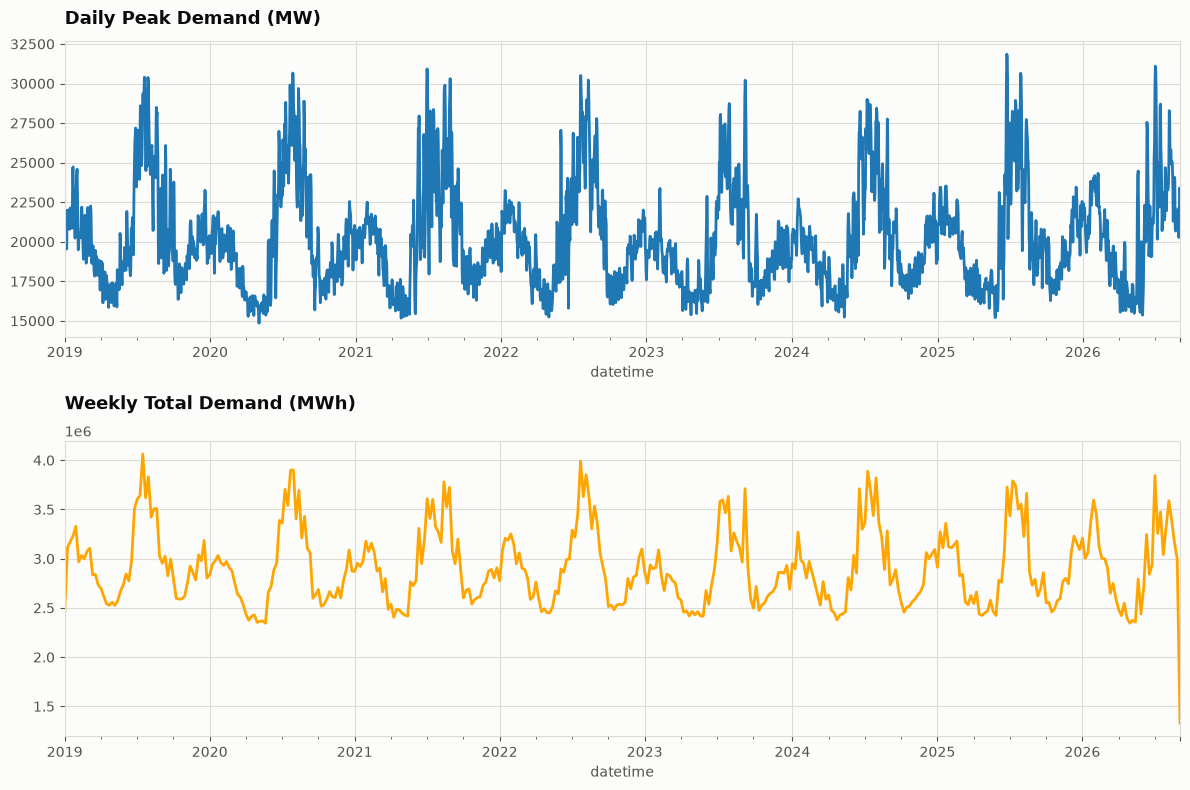

In [22]:
demand_daily = demand_hourly.resample("D").agg(
    daily_peak_mw=("demand_mwh", "max"),
    daily_total_mwh=("demand_mwh", "sum"),
).dropna()

demand_weekly = demand_hourly.resample("W-SUN").agg(
    weekly_total_mwh=("demand_mwh", "sum"),
).dropna()

print("Daily:", demand_daily.shape)
print("Weekly:", demand_weekly.shape)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
demand_daily["daily_peak_mw"].plot(ax=axes[0], title="Daily Peak Demand (MW)")
demand_weekly["weekly_total_mwh"].plot(ax=axes[1], title="Weekly Total Demand (MWh)", color="orange")
plt.tight_layout()
plt.show()


## 2b. What actually drives demand

Four questions worth answering before modelling anything, because each one
either justifies a feature or kills it:

1. **When in the day does load peak, and does that shift by season?** -> tells us
   whether a daily-peak target hides two different physical regimes.
2. **Is the seasonal shape stable year over year?** -> tells us whether 2019
   training data is still relevant to 2026.
3. **How wide is the within-month spread?** -> sets a floor on achievable error.
4. **What does load do as temperature moves?** -> the single most important
   relationship in load forecasting, and the justification for HDD/CDD.

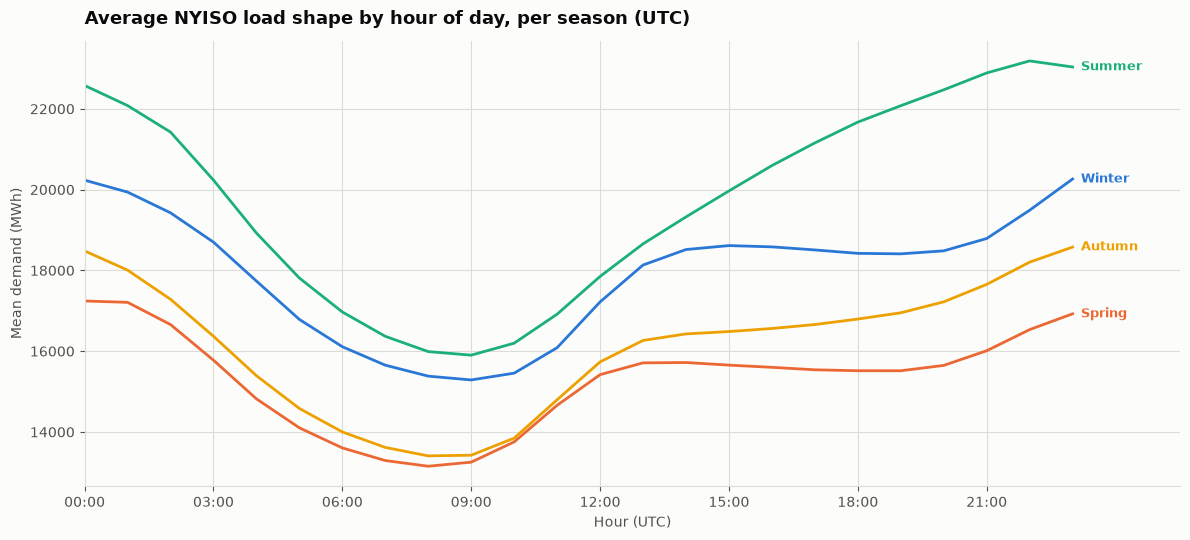

Summer peaks at hour 22 UTC (= 18:00 EDT), winter at hour 23 UTC (= 18:00 EST)
Summer peak is +14.4% vs winter peak


In [23]:
# Average hourly load shape, split by season. Seasons are meteorological
# (Dec-Feb winter, etc.) rather than astronomical - they line up with load.
SEASONS = {12: "Winter", 1: "Winter", 2: "Winter",
           3: "Spring", 4: "Spring", 5: "Spring",
           6: "Summer", 7: "Summer", 8: "Summer",
           9: "Autumn", 10: "Autumn", 11: "Autumn"}

prof = demand_hourly.copy()
prof["hour"] = prof.index.hour
prof["season"] = prof.index.month.map(SEASONS)

shape = prof.pivot_table(index="hour", columns="season", values="demand_mwh", aggfunc="mean")
shape = shape[["Winter", "Spring", "Summer", "Autumn"]]  # fixed slot order

fig, ax = plt.subplots(figsize=(12, 5.5))
for season, color in zip(shape.columns, [C["blue"], C["orange"], C["aqua"], C["yellow"]]):
    ax.plot(shape.index, shape[season], color=color)
    label_line(ax, shape.index[-1], shape[season].iloc[-1], season, color)

ax.set_xlim(0, 25.5)
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)])
ax.set_title("Average NYISO load shape by hour of day, per season (UTC)")
tidy(ax, ylabel="Mean demand (MWh)", xlabel="Hour (UTC)")
plt.tight_layout()
plt.show()

summer_peak_hr = int(shape["Summer"].idxmax())
winter_peak_hr = int(shape["Winter"].idxmax())
print(f"Summer peaks at hour {summer_peak_hr:02d} UTC "
      f"(= {(summer_peak_hr - 4) % 24:02d}:00 EDT), "
      f"winter at hour {winter_peak_hr:02d} UTC (= {(winter_peak_hr - 5) % 24:02d}:00 EST)")
print(f"Summer peak is {shape['Summer'].max() / shape['Winter'].max() - 1:+.1%} vs winter peak")

Summer and winter peak at **different hours** and for different reasons -
afternoon air-conditioning versus an evening lighting/heating ramp. That is the
physical reason a single linear temperature term cannot work, and why the
feature set below splits temperature into HDD and CDD instead.

> **Timezone caveat.** EIA's `hourly` frequency returns **UTC**, and this notebook
> never converts it. Both curves peak around 18:00 local once you subtract the
> offset, which is the physically sensible answer - but it means `daily_peak_mw`
> is the max over a *UTC* day, whose boundary falls at 19:00/20:00 local and so
> cuts through the local evening ramp. Some days therefore attribute their peak
> to the neighbouring calendar day. Switching the EIA request to
> `frequency="local-hourly"` fixes it, at the cost of re-scoring everything below.


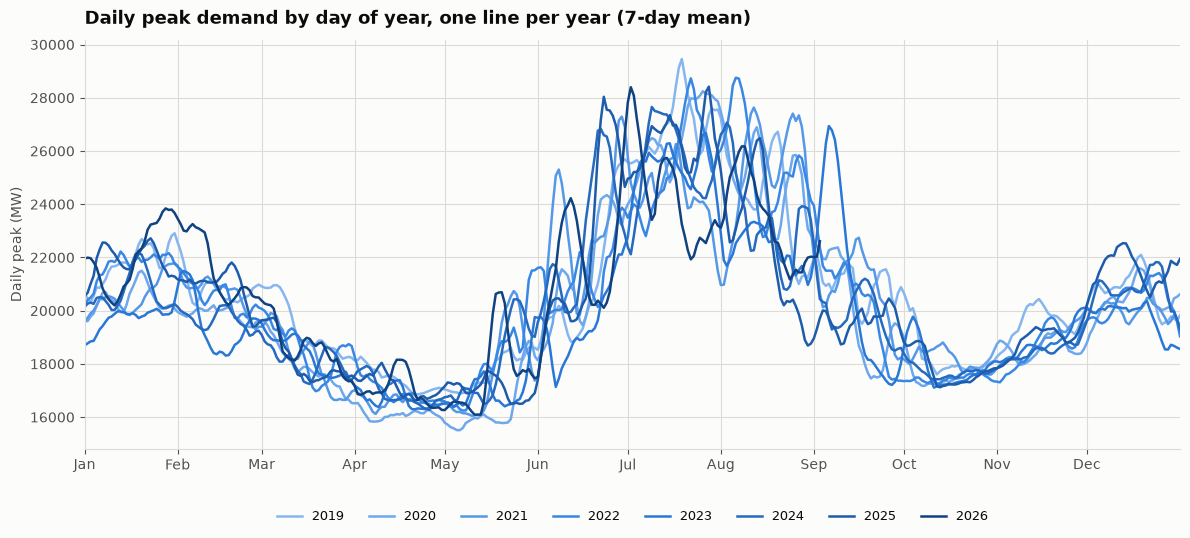

Annual maximum peak (MW):
year
2019    30397.0
2020    30660.0
2021    30919.0
2022    30505.0
2023    30206.0
2024    28990.0
2025    31857.0
2026    31097.0


In [24]:
# Year-over-year overlay of daily peak, smoothed with a 7-day centred mean so
# the seasonal shape is visible through the weekday/weekend sawtooth.
yoy = demand_daily.copy()
yoy["year"] = yoy.index.year
yoy["doy"] = yoy.index.dayofyear
grid = yoy.pivot_table(index="doy", columns="year", values="daily_peak_mw")
grid = grid.rolling(7, center=True, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
years = sorted(grid.columns)
# Ordered magnitude -> one hue, light to dark. Older years recede, recent
# years dominate, which is the reading order we want.
for year, color in zip(years, SEQ_BLUE[-len(years):]):
    ax.plot(grid.index, grid[year], color=color, linewidth=1.8, label=str(year))

ax.legend(ncol=len(years), loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
ax.set_xticks(month_starts)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_xlim(1, 366)
ax.set_title("Daily peak demand by day of year, one line per year (7-day mean)")
tidy(ax, ylabel="Daily peak (MW)")
plt.tight_layout()
plt.show()

annual = yoy.groupby("year")["daily_peak_mw"].max()
print("Annual maximum peak (MW):")
print(annual.to_string())

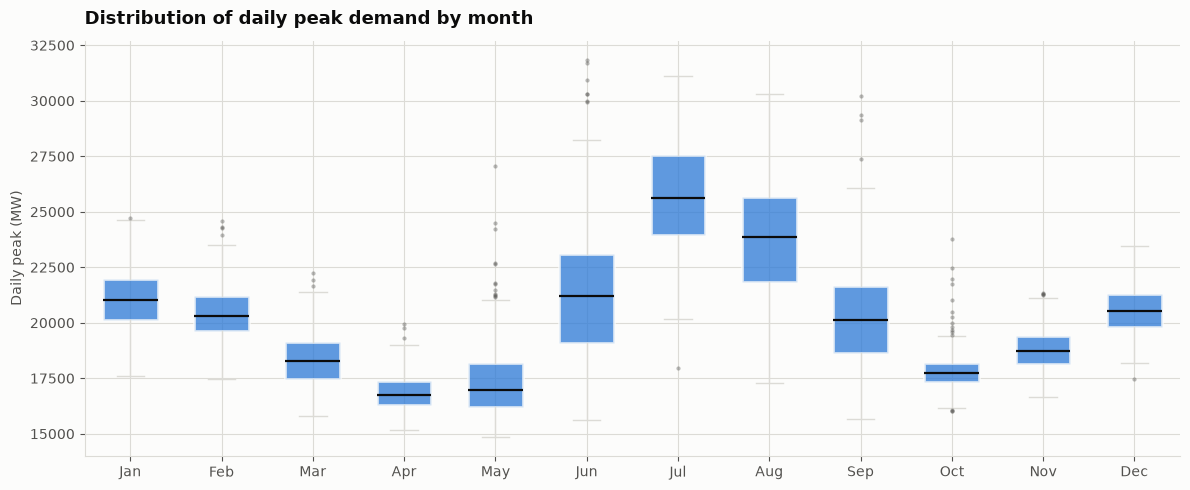

Widest month (std): 6 at 3,222 MW
Tightest month (std): 4 at 861 MW


In [25]:
# Within-month spread. The box height is roughly the error a model that knew
# only the month would make - a useful sanity floor for the metrics later.
fig, ax = plt.subplots(figsize=(12, 5))
by_month = [demand_daily.loc[demand_daily.index.month == m, "daily_peak_mw"].values
            for m in range(1, 13)]
bp = ax.boxplot(by_month, patch_artist=True, widths=0.6,
                medianprops=dict(color=INK, linewidth=1.6),
                flierprops=dict(marker="o", markersize=3, markerfacecolor=INK_SOFT,
                                markeredgecolor="none", alpha=0.4))
for patch in bp["boxes"]:
    patch.set_facecolor(C["blue"])
    patch.set_alpha(0.75)
    patch.set_edgecolor(SURFACE)     # 2px surface gap between adjacent fills
    patch.set_linewidth(2)
for element in ("whiskers", "caps"):
    for line in bp[element]:
        line.set_color(GRID)

ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Distribution of daily peak demand by month")
tidy(ax, ylabel="Daily peak (MW)")
plt.tight_layout()
plt.show()

spread = demand_daily.groupby(demand_daily.index.month)["daily_peak_mw"].agg(["median", "std"])
print(f"Widest month (std): {spread['std'].idxmax()} at {spread['std'].max():,.0f} MW")
print(f"Tightest month (std): {spread['std'].idxmin()} at {spread['std'].min():,.0f} MW")

## 3. Pull NOAA daily weather (LaGuardia station)

NCEI's CDO API also paginates (max 1000 records/call) and is limited to 1-year windows per request, so we loop by year.


In [26]:
def fetch_noaa_daily(token, station_id, start_date, end_date):
    """
    Pull daily TMAX/TMIN/PRCP for a station, looping year-by-year
    (CDO API caps date ranges at 1 year per request).
    """
    base_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"
    headers = {"token": token}
    all_rows = []

    years = pd.date_range(start_date, end_date, freq="YS")
    if len(years) == 0:
        years = pd.DatetimeIndex([pd.Timestamp(start_date)])

    for year_start in years:
        year_end = min(year_start + pd.DateOffset(years=1) - pd.Timedelta(days=1),
                        pd.Timestamp(end_date))
        offset = 1
        while True:
            params = {
                "datasetid": "GHCND",
                "stationid": station_id,
                "startdate": year_start.strftime("%Y-%m-%d"),
                "enddate": year_end.strftime("%Y-%m-%d"),
                "datatypeid": ["TMAX", "TMIN", "PRCP"],
                "units": "standard",
                "limit": 1000,
                "offset": offset,
            }
            resp = requests.get(base_url, headers=headers, params=params, timeout=30)
            resp.raise_for_status()
            payload = resp.json()
            rows = payload.get("results", [])
            if not rows:
                break
            all_rows.extend(rows)
            if len(rows) < 1000:
                break
            offset += 1000
            time.sleep(0.3)

        print(f"  {year_start.year}: total rows so far {len(all_rows)}")
        time.sleep(0.3)

    return pd.DataFrame(all_rows)


print("Fetching LaGuardia daily weather from NOAA...")
noaa_raw = fetch_noaa_daily(NOAA_TOKEN, NOAA_STATION_ID, START_DATE, END_DATE)
noaa_raw.head()


Fetching LaGuardia daily weather from NOAA...
  2019: total rows so far 1095
  2020: total rows so far 2193
  2021: total rows so far 3288
  2022: total rows so far 4383
  2023: total rows so far 5478
  2024: total rows so far 6576
  2025: total rows so far 7671
  2026: total rows so far 8397


,date,datatype,station,attributes,value
0,2019-01-01T00:00:00,PRCP,GHCND:USW00014732,",,W,2400",0.08
1,2019-01-01T00:00:00,TMAX,GHCND:USW00014732,",,W,2400",60.00
2,2019-01-01T00:00:00,TMIN,GHCND:USW00014732,",,W,2400",40.00
3,2019-01-02T00:00:00,PRCP,GHCND:USW00014732,",,W,2400",0.00
4,2019-01-02T00:00:00,TMAX,GHCND:USW00014732,",,W,2400",41.00


In [27]:
# Pivot NOAA long format (one row per datatype per day) into wide daily columns
noaa_raw["date"] = pd.to_datetime(noaa_raw["date"]).dt.normalize()
weather_daily = noaa_raw.pivot_table(index="date", columns="datatype", values="value", aggfunc="first")
weather_daily.columns = [c.lower() for c in weather_daily.columns]
weather_daily = weather_daily.rename(columns={"tmax": "temp_max_f", "tmin": "temp_min_f", "prcp": "precip_in"})
weather_daily["temp_avg_f"] = (weather_daily["temp_max_f"] + weather_daily["temp_min_f"]) / 2

print(f"Weather daily rows: {len(weather_daily)}")
weather_daily.head()


Weather daily rows: 2799


,precip_in,temp_max_f,temp_min_f,temp_avg_f
date,,,,
2019-01-01,0.08,60.0,40.0,50.0
2019-01-02,0.00,41.0,35.0,38.0
2019-01-03,0.00,45.0,39.0,42.0
2019-01-04,0.00,47.0,37.0,42.0
2019-01-05,0.45,47.0,42.0,44.5


## 4. Merge demand + weather, engineer features

In [28]:
demand_daily.index.name = "date"
df = demand_daily.join(weather_daily, how="inner")
df = df.sort_index()

print(f"Merged daily dataset: {df.shape}")
df.head()


Merged daily dataset: (2799, 6)


,daily_peak_mw,daily_total_mwh,precip_in,temp_max_f,temp_min_f,temp_avg_f
date,,,,,,
2019-01-01,19586.0,382386.0,0.08,60.0,40.0,50.0
2019-01-02,21109.0,421132.0,0.00,41.0,35.0,38.0
2019-01-03,20963.0,432247.0,0.00,45.0,39.0,42.0
2019-01-04,20775.0,428916.0,0.00,47.0,37.0,42.0
2019-01-05,19891.0,403970.0,0.45,47.0,42.0,44.5


### The temperature response curve

This is the chart that justifies the whole feature set. Load against temperature
is **not linear and not monotonic** - it is a U (or hockey stick), because both
cold and heat create load through different appliances. A single `temp_avg_f`
coefficient would fit the bottom of the U and miss both arms, which is exactly
what heating- and cooling-degree-days are designed to fix:

    hdd = max(0, 65 - temp_avg_f)     # how far below the comfort point
    cdd = max(0, temp_avg_f - 65)     # how far above it

Splitting one variable into two half-line variables lets a model put a
different slope on each arm.

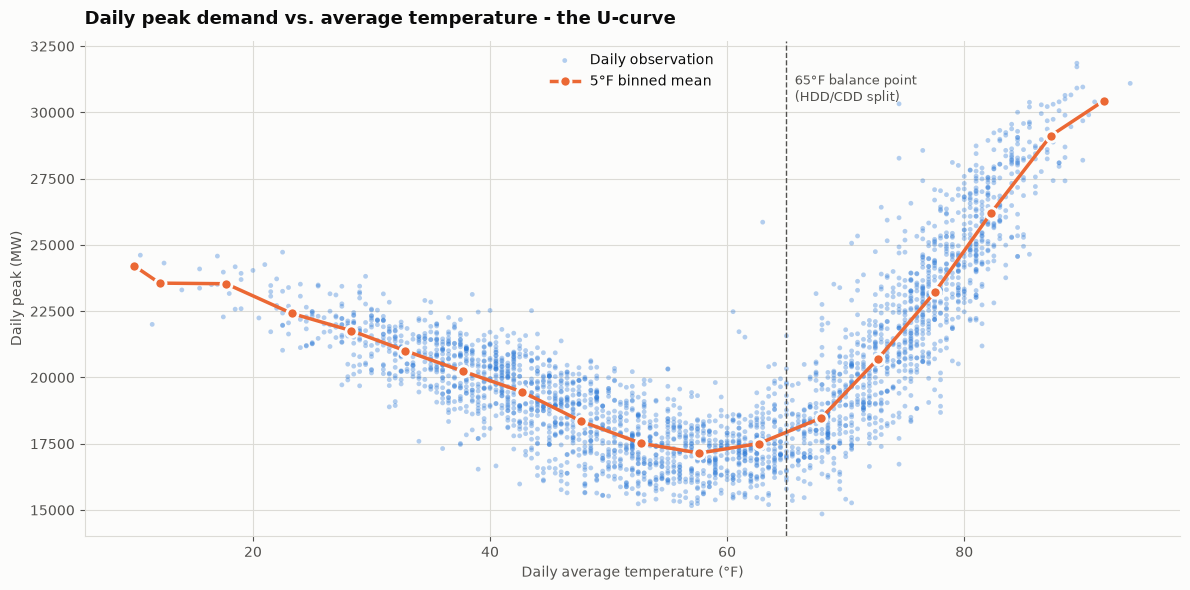

Mean daily peak - cold (<40F): 21,011 MW
Mean daily peak - mild (55-65F): 17,361 MW
Mean daily peak - hot (>78F): 26,090 MW

Heat drives peaks +50% above mild days; cold +21%.
Note the asymmetry: NYISO is a summer-peaking system.


In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

# Every day as a point, plus the binned conditional mean on top so the shape
# reads through the scatter.
ax.scatter(df["temp_avg_f"], df["daily_peak_mw"],
           s=12, color=C["blue"], alpha=0.35, edgecolors="none", label="Daily observation")

bins = pd.cut(df["temp_avg_f"], bins=np.arange(0, 100, 5))
binned = df.groupby(bins, observed=True).agg(
    temp=("temp_avg_f", "mean"), peak=("daily_peak_mw", "mean")).dropna()
ax.plot(binned["temp"], binned["peak"], color=C["orange"], linewidth=2.5,
        marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2,
        label="5\u00b0F binned mean")

ax.axvline(65, color=INK_SOFT, linestyle="--", linewidth=1)
ax.annotate("65\u00b0F balance point\n(HDD/CDD split)", xy=(65, ax.get_ylim()[1] * 0.97),
            xytext=(6, -4), textcoords="offset points", fontsize=9,
            color=INK_SOFT, va="top")

ax.set_title("Daily peak demand vs. average temperature - the U-curve")
tidy(ax, ylabel="Daily peak (MW)", xlabel="Daily average temperature (\u00b0F)")
ax.legend(loc="upper center")
plt.tight_layout()
plt.show()

cold = df[df["temp_avg_f"] < 40]["daily_peak_mw"].mean()
mild = df[(df["temp_avg_f"] >= 55) & (df["temp_avg_f"] <= 65)]["daily_peak_mw"].mean()
hot  = df[df["temp_avg_f"] > 78]["daily_peak_mw"].mean()
print(f"Mean daily peak - cold (<40F): {cold:,.0f} MW")
print(f"Mean daily peak - mild (55-65F): {mild:,.0f} MW")
print(f"Mean daily peak - hot (>78F): {hot:,.0f} MW")
print(f"\nHeat drives peaks {hot / mild - 1:+.0%} above mild days; cold {cold / mild - 1:+.0%}.")
print("Note the asymmetry: NYISO is a summer-peaking system.")

In [30]:
def add_features(df):
    df = df.copy()

    # Calendar features
    df["day_of_week"] = df.index.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["month"] = df.index.month
    df["day_of_year"] = df.index.dayofyear

    # US federal holidays (rough proxy — refine later with `holidays` package)
    try:
        import holidays as holidays_pkg
        us_holidays = holidays_pkg.US(years=range(df.index.year.min(), df.index.year.max() + 1))
        df["is_holiday"] = df.index.to_series().apply(lambda d: d in us_holidays).astype(int)
    except ImportError:
        df["is_holiday"] = 0  # fallback if `holidays` isn't installed

    # Lagged demand features (yesterday, same day last week, same day 2 weeks ago)
    df["peak_lag_1"] = df["daily_peak_mw"].shift(1)
    df["peak_lag_7"] = df["daily_peak_mw"].shift(7)
    df["peak_lag_14"] = df["daily_peak_mw"].shift(14)

    # Rolling averages of demand
    df["peak_roll_mean_7"] = df["daily_peak_mw"].shift(1).rolling(7).mean()
    df["peak_roll_mean_14"] = df["daily_peak_mw"].shift(1).rolling(14).mean()

    # Weather-derived features — heating/cooling degree days (base 65F)
    df["hdd"] = (65 - df["temp_avg_f"]).clip(lower=0)
    df["cdd"] = (df["temp_avg_f"] - 65).clip(lower=0)
    df["temp_lag_1"] = df["temp_avg_f"].shift(1)

    return df


df_feat = add_features(df)
df_feat = df_feat.dropna()  # drop rows with NaN from lag/rolling windows
print(f"Feature dataset after dropping NaNs from lags: {df_feat.shape}")
df_feat.head()


Feature dataset after dropping NaNs from lags: (2785, 19)


,daily_peak_mw,daily_total_mwh,precip_in,temp_max_f,temp_min_f,temp_avg_f,day_of_week,is_weekend,month,day_of_year,is_holiday,peak_lag_1,peak_lag_7,peak_lag_14,peak_roll_mean_7,peak_roll_mean_14,hdd,cdd,temp_lag_1
date,,,,,,,,,,,,,,,,,,,
2019-01-15,22139.0,464676.0,0.00,36.0,26.0,31.0,1,0,1,15,0,22064.0,21814.0,19586.0,21666.285714,21108.642857,34.0,0.0,28.5
2019-01-16,21701.0,455159.0,0.00,40.0,31.0,35.5,2,0,1,16,0,22139.0,21046.0,21109.0,21712.714286,21291.000000,29.5,0.0,31.0
2019-01-17,21986.0,461023.0,0.00,34.0,26.0,30.0,3,0,1,17,0,21701.0,21968.0,20963.0,21806.285714,21333.285714,35.0,0.0,35.5
2019-01-18,21945.0,457752.0,0.03,42.0,29.0,35.5,4,0,1,18,0,21986.0,21997.0,20775.0,21808.857143,21406.357143,29.5,0.0,30.0
2019-01-19,20850.0,434527.0,0.34,39.0,32.0,35.5,5,1,1,19,0,21945.0,21990.0,19891.0,21801.428571,21489.928571,29.5,0.0,35.5


### Feature dictionary

| Feature | Type | Definition | Why it's here |
|---|---|---|---|
| `temp_max_f`, `temp_min_f`, `temp_avg_f` | weather | Daily LaGuardia temps (°F) | Primary physical driver of load |
| `precip_in` | weather | Daily precipitation (in) | Weak, but cloud cover shifts lighting/AC load |
| `hdd`, `cdd` | weather | `max(0, 65-T)`, `max(0, T-65)` | Linearises each arm of the U-curve above |
| `temp_lag_1` | weather | Yesterday's mean temp | Buildings have thermal mass; heat carries over |
| `day_of_week`, `is_weekend` | calendar | 0-6, and weekend flag | Commercial/industrial load collapses at weekends |
| `month`, `day_of_year` | calendar | Seasonal position | Captures daylight and non-temperature seasonality |
| `is_holiday` | calendar | US federal holiday flag | Holidays behave like weekends regardless of weekday |
| `peak_lag_1`, `peak_lag_7`, `peak_lag_14` | autoregressive | Peak 1/7/14 days ago | Load is highly persistent; lag-7 preserves day-of-week phase |
| `peak_roll_mean_7`, `peak_roll_mean_14` | autoregressive | Trailing means, **shifted 1 day** | Recent level without leaking today's value |

**On leakage:** every autoregressive feature is `.shift(1)` before any rolling
window, so no feature contains information from the day being predicted. This is
the single easiest mistake to make in time-series feature engineering, and it
produces spectacular validation scores that vanish in production.

**Operating assumption:** these lags mean the model is a **day-ahead** forecaster -
it assumes yesterday's actual peak is known at prediction time. That is true for
day-ahead planning and false for anything further out. A 7-day-ahead model would
have to drop `peak_lag_1` entirely.

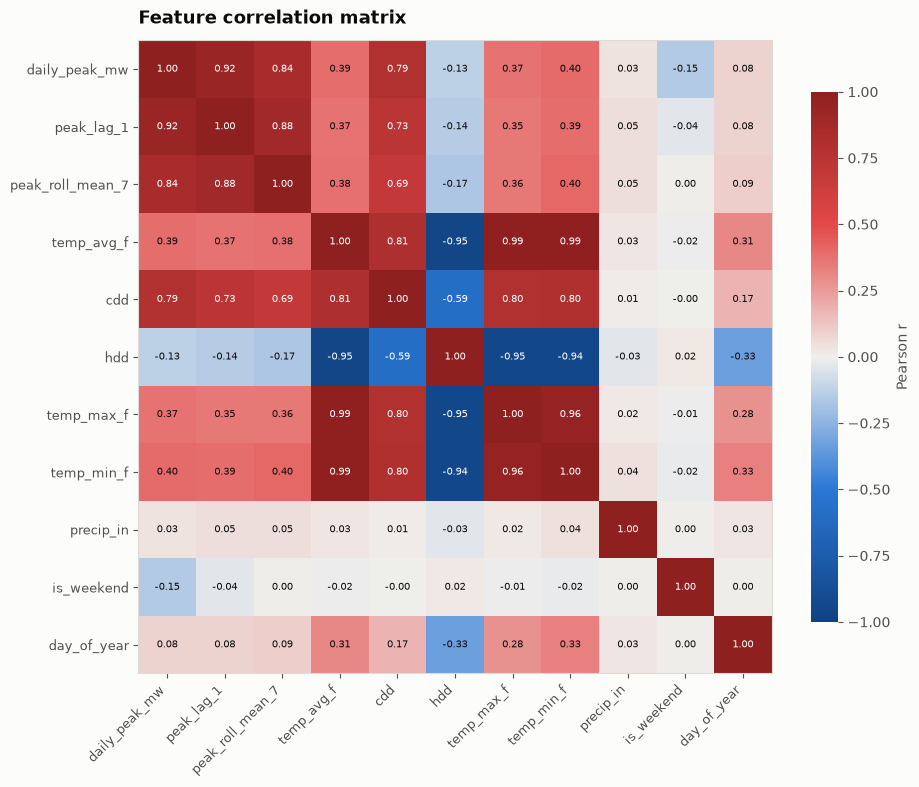

Correlation with daily_peak_mw, strongest first:
peak_lag_1          0.924878
peak_roll_mean_7    0.837456
cdd                 0.793065
temp_min_f          0.396684
temp_avg_f          0.389106
temp_max_f          0.374572
is_weekend         -0.149270
hdd                -0.128248
day_of_year         0.083440
precip_in           0.033940


In [31]:
# Correlation of each feature with the target and with each other.
# Signed quantity -> diverging scale, two hues either side of a neutral gray.
corr_cols = FEATURE_COLS_PREVIEW = [
    "daily_peak_mw", "peak_lag_1", "peak_roll_mean_7", "temp_avg_f", "cdd", "hdd",
    "temp_max_f", "temp_min_f", "precip_in", "is_weekend", "day_of_year",
]
corr = df_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=9)
ax.grid(False)

# Values on the cells: the heatmap shows pattern, the numbers let you read it.
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if abs(v) > 0.55 else INK)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pearson r", color=INK_SOFT)
cbar.outline.set_visible(False)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

target_corr = corr["daily_peak_mw"].drop("daily_peak_mw").sort_values(key=abs, ascending=False)
print("Correlation with daily_peak_mw, strongest first:")
print(target_corr.to_string())

## 5. Train/validation split

Time series → **no random shuffling**. Hold out the most recent ~8 weeks as validation to simulate the real forecasting scenario.


In [32]:
FEATURE_COLS = [
    "temp_max_f", "temp_min_f", "temp_avg_f", "precip_in", "hdd", "cdd", "temp_lag_1",
    "day_of_week", "is_weekend", "month", "day_of_year", "is_holiday",
    "peak_lag_1", "peak_lag_7", "peak_lag_14", "peak_roll_mean_7", "peak_roll_mean_14",
]
TARGET_COL = "daily_peak_mw"

VALIDATION_WEEKS = 8
split_date = df_feat.index.max() - pd.Timedelta(weeks=VALIDATION_WEEKS)

train_df = df_feat[df_feat.index <= split_date]
val_df = df_feat[df_feat.index > split_date]

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val, y_val = val_df[FEATURE_COLS], val_df[TARGET_COL]

print(f"Train: {X_train.shape}, {train_df.index.min()} to {train_df.index.max()}")
print(f"Val:   {X_val.shape}, {val_df.index.min()} to {val_df.index.max()}")


Train: (2729, 17), 2019-01-15 00:00:00 to 2026-07-05 00:00:00
Val:   (56, 17), 2026-07-06 00:00:00 to 2026-08-30 00:00:00


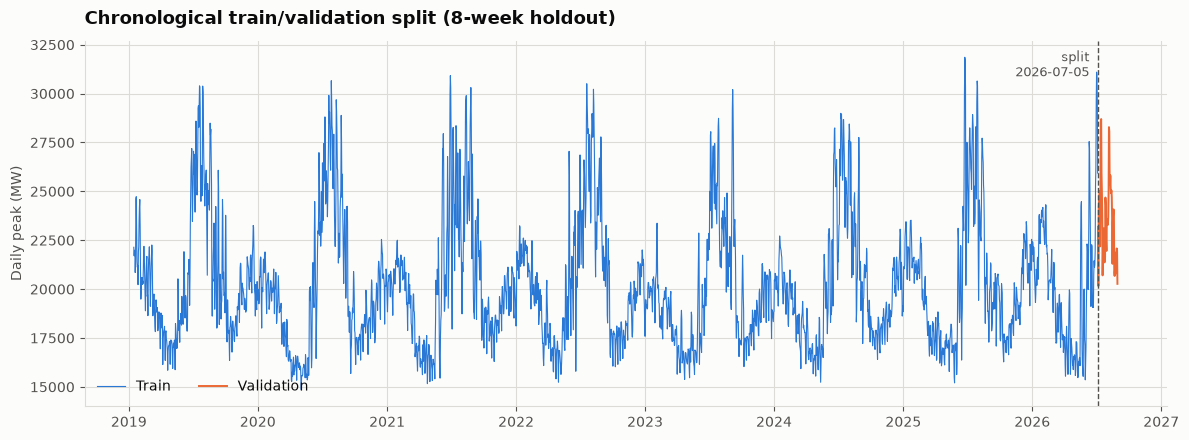

Train: 2,729 days (98.0%)
Val:   56 days (2.0%)
Validation window covers Jul 06 to Aug 30 - a summer period, so these numbers describe cooling-season performance specifically.


In [33]:
# Show the split on the timeline. A chronological holdout is the only honest
# option here: shuffling would let the model see next week while predicting
# last week, via peak_lag_1 alone.
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(train_df.index, train_df[TARGET_COL], color=C["blue"], linewidth=0.8, label="Train")
ax.plot(val_df.index, val_df[TARGET_COL], color=C["orange"], linewidth=1.4, label="Validation")
ax.axvline(split_date, color=INK_SOFT, linestyle="--", linewidth=1)
ax.annotate(f"split\n{split_date:%Y-%m-%d}", xy=(split_date, ax.get_ylim()[1]),
            xytext=(-6, -6), textcoords="offset points", ha="right", va="top",
            fontsize=9, color=INK_SOFT)
ax.set_title(f"Chronological train/validation split ({VALIDATION_WEEKS}-week holdout)")
tidy(ax, ylabel="Daily peak (MW)")
ax.legend(loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

print(f"Train: {len(train_df):,} days ({len(train_df)/len(df_feat):.1%})")
print(f"Val:   {len(val_df):,} days ({len(val_df)/len(df_feat):.1%})")
print(f"Validation window covers {val_df.index.min():%b %d} to {val_df.index.max():%b %d} "
      f"- a {'summer' if val_df.index.month.isin([6,7,8]).mean() > 0.5 else 'mixed'} period, "
      "so these numbers describe cooling-season performance specifically.")

## 6. Train XGBoost + log to MLflow

In [34]:
import mlflow
import mlflow.xgboost
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

mlflow.set_experiment("nyiso-daily-peak-demand")

params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
}

with mlflow.start_run(run_name="xgb_daily_peak_v1") as run:
    mlflow.log_params(params)
    mlflow.log_param("validation_weeks", VALIDATION_WEEKS)
    mlflow.log_param("n_features", len(FEATURE_COLS))
    mlflow.log_param("train_start", str(train_df.index.min()))
    mlflow.log_param("train_end", str(train_df.index.max()))

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    mape = mean_absolute_percentage_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    mlflow.log_metric("val_mae", mae)
    mlflow.log_metric("val_mape", mape)
    mlflow.log_metric("val_rmse", rmse)

    mlflow.xgboost.log_model(model, artifact_path="model")

    print(f"Run ID: {run.info.run_id}")
    print(f"MAE:  {mae:.2f} MW")
    print(f"MAPE: {mape:.2%}")
    print(f"RMSE: {rmse:.2f} MW")


2026/09/02 17:56:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run ID: 228f492120a449e9bd034f295648ac25
MAE:  747.40 MW
MAPE: 3.21%
RMSE: 914.85 MW


## 6b. Does the model beat doing nothing?

An MAE of a few hundred MW means nothing on its own. The number that matters is
whether it beats the **persistence baseline** - "tomorrow's peak equals today's
peak", which is `peak_lag_1` used directly as the prediction and costs zero to
compute.

This matters more than usual here because `peak_lag_1` is also the model's
single most important feature. Without this comparison there is no way to tell
whether XGBoost learned the weather response or simply learned to echo
yesterday.

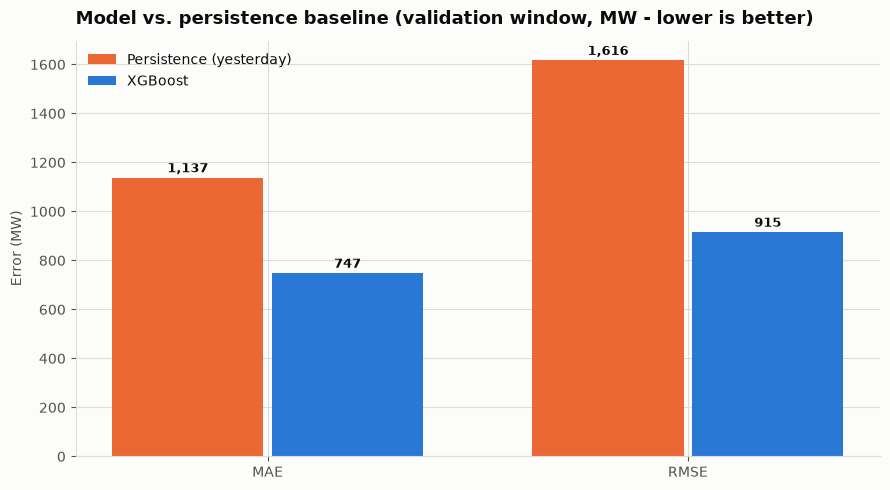

      Persistence  XGBoost  Improvement
MAE       1137.34   747.40         0.34
RMSE      1616.19   914.85         0.43
MAPE         4.85     3.21         0.34

MAE improvement over persistence: 34.3%
This is the number that says the result is real rather than peak_lag_1 wearing a hat.


In [35]:
# Persistence: predict today's peak as yesterday's peak.
baseline_preds = val_df["peak_lag_1"].values

def score(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

model_scores    = score(y_val, preds)
baseline_scores = score(y_val, baseline_preds)

comparison = pd.DataFrame({"Persistence": baseline_scores, "XGBoost": model_scores})
comparison["Improvement"] = (1 - comparison["XGBoost"] / comparison["Persistence"])

fig, ax = plt.subplots(figsize=(9, 5))
metrics = ["MAE", "RMSE"]          # both in MW - one axis, never two scales
x = np.arange(len(metrics))
width = 0.36
b1 = ax.bar(x - width/2 - 0.01, [baseline_scores[m] for m in metrics], width,
            color=C["orange"], label="Persistence (yesterday)")
b2 = ax.bar(x + width/2 + 0.01, [model_scores[m] for m in metrics], width,
            color=C["blue"], label="XGBoost")

for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():,.0f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9, color=INK, weight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Model vs. persistence baseline (validation window, MW - lower is better)")
tidy(ax, ylabel="Error (MW)")
ax.legend()
plt.tight_layout()
plt.show()

print(comparison.round(2).to_string())
print(f"\nMAE improvement over persistence: {comparison.loc['MAE', 'Improvement']:.1%}")
print("This is the number that says the result is real rather than peak_lag_1 wearing a hat.")

## 7. Inspect predictions vs. actuals

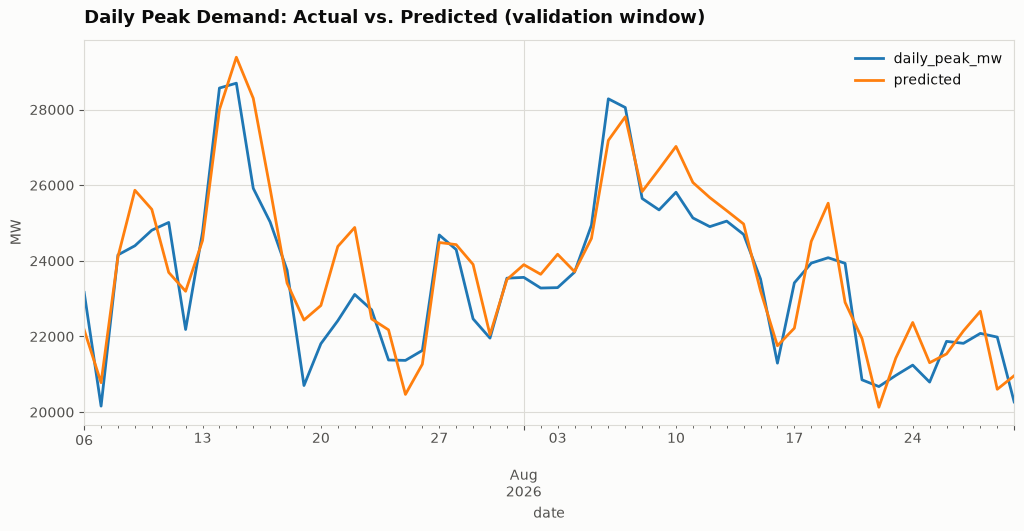

,daily_peak_mw,predicted,error
date,,,
2026-08-16,21294.0,21754.394531,460.394531
2026-08-17,23417.0,22218.687500,-1198.312500
2026-08-18,23939.0,24513.275391,574.275391
2026-08-19,24082.0,25523.302734,1441.302734
2026-08-20,23934.0,22902.699219,-1031.300781
2026-08-21,20853.0,21946.224609,1093.224609
2026-08-22,20675.0,20128.931641,-546.068359
2026-08-23,20969.0,21427.980469,458.980469
2026-08-24,21242.0,22369.638672,1127.638672


In [36]:
results = val_df[[TARGET_COL]].copy()
results["predicted"] = preds
results["error"] = results["predicted"] - results[TARGET_COL]

fig, ax = plt.subplots(figsize=(12, 5))
results[[TARGET_COL, "predicted"]].plot(ax=ax, title="Daily Peak Demand: Actual vs. Predicted (validation window)")
plt.ylabel("MW")
plt.show()

results.tail(15)


## 7b. Residual diagnostics

Aggregate metrics hide *where* a model fails. Three questions:

- **Is error unbiased?** A residual mean far from zero means systematic over- or
  under-forecasting, which is worse than noise for a grid operator - it biases
  reserve procurement in one direction every day.
- **Does error grow with load?** Heteroscedasticity on the high end is the
  expensive kind: the peak days are exactly the ones that matter.
- **Is error autocorrelated?** Runs of same-sign error mean a regime the model
  has not learned, not random noise.

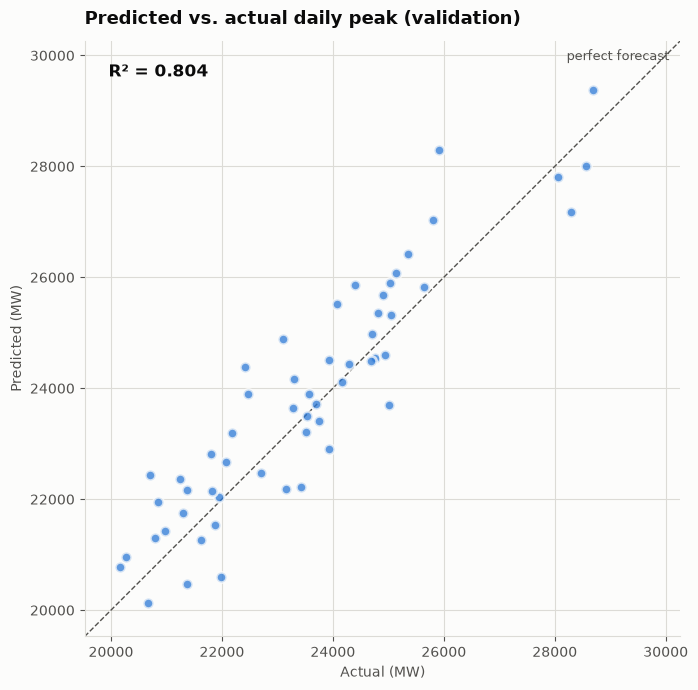

In [37]:
fig, ax = plt.subplots(figsize=(7.5, 7))
lim = [min(y_val.min(), preds.min()) * 0.97, max(y_val.max(), preds.max()) * 1.03]

ax.plot(lim, lim, color=INK_SOFT, linestyle="--", linewidth=1, zorder=1)
ax.annotate("perfect forecast", xy=(lim[1], lim[1]), xytext=(-8, -14),
            textcoords="offset points", ha="right", fontsize=9, color=INK_SOFT)
ax.scatter(y_val, preds, s=55, color=C["blue"], alpha=0.75,
           edgecolors=SURFACE, linewidths=2, zorder=2)   # 2px surface ring

ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_title("Predicted vs. actual daily peak (validation)")
tidy(ax, xlabel="Actual (MW)", ylabel="Predicted (MW)")

ss_res = ((y_val - preds) ** 2).sum()
ss_tot = ((y_val - y_val.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
ax.annotate(f"R\u00b2 = {r2:.3f}", xy=(0.04, 0.94), xycoords="axes fraction",
            fontsize=12, color=INK, weight="bold")
plt.tight_layout()
plt.show()

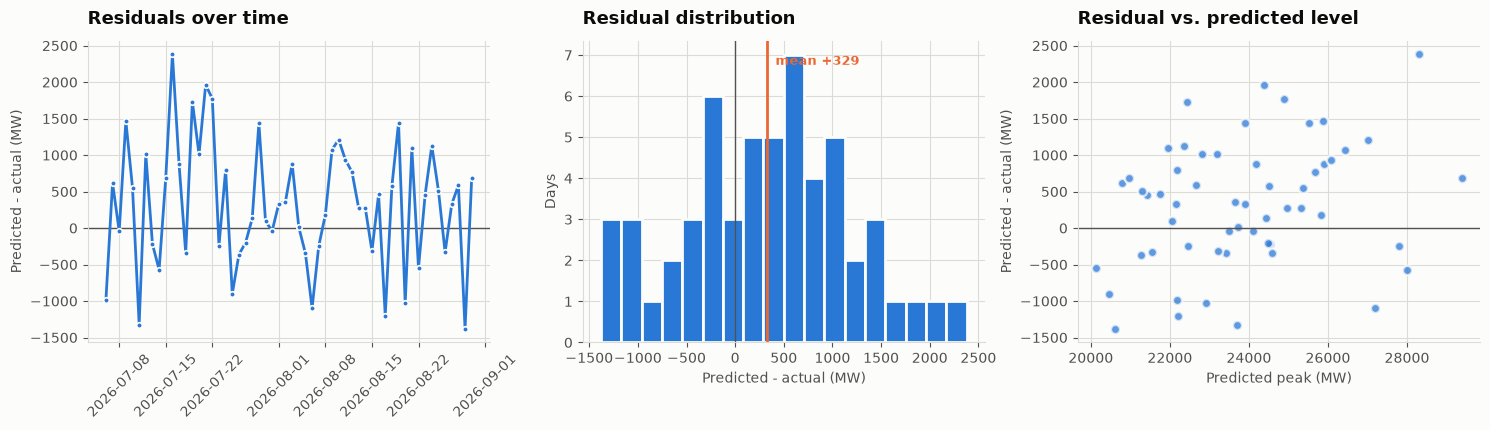

Residual mean:      +328.7 MW   (0 = unbiased)
Residual std:       861.5 MW
Lag-1 autocorr:     +0.013   (0 = no exploitable structure left)
Worst single day:   2026-07-16, 2,380 MW off


In [38]:
resid = pd.Series(preds - y_val.values, index=y_val.index, name="residual")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# 1. Residuals over time - looking for runs of one sign.
axes[0].axhline(0, color=INK_SOFT, linewidth=1)
axes[0].plot(resid.index, resid.values, color=C["blue"], marker="o", markersize=4,
             markeredgecolor=SURFACE, markeredgewidth=1.2)
axes[0].set_title("Residuals over time")
tidy(axes[0], ylabel="Predicted - actual (MW)")
axes[0].tick_params(axis="x", rotation=45)

# 2. Distribution - looking for bias and fat tails.
axes[1].axvline(0, color=INK_SOFT, linewidth=1)
axes[1].hist(resid.values, bins=18, color=C["blue"], edgecolor=SURFACE, linewidth=2)
axes[1].axvline(resid.mean(), color=C["orange"], linewidth=2)
axes[1].annotate(f"mean {resid.mean():+,.0f}", xy=(resid.mean(), axes[1].get_ylim()[1] * 0.92),
                 xytext=(6, 0), textcoords="offset points", fontsize=9,
                 color=C["orange"], weight="bold")
axes[1].set_title("Residual distribution")
tidy(axes[1], xlabel="Predicted - actual (MW)", ylabel="Days")

# 3. Residual vs. fitted - looking for a fan shape.
axes[2].axhline(0, color=INK_SOFT, linewidth=1)
axes[2].scatter(preds, resid.values, s=45, color=C["blue"], alpha=0.75,
                edgecolors=SURFACE, linewidths=1.8)
axes[2].set_title("Residual vs. predicted level")
tidy(axes[2], xlabel="Predicted peak (MW)", ylabel="Predicted - actual (MW)")

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr
runs_corr = pearsonr(resid.values[:-1], resid.values[1:])[0]
print(f"Residual mean:      {resid.mean():+,.1f} MW   (0 = unbiased)")
print(f"Residual std:       {resid.std():,.1f} MW")
print(f"Lag-1 autocorr:     {runs_corr:+.3f}   (0 = no exploitable structure left)")
print(f"Worst single day:   {resid.abs().idxmax():%Y-%m-%d}, {resid.abs().max():,.0f} MW off")

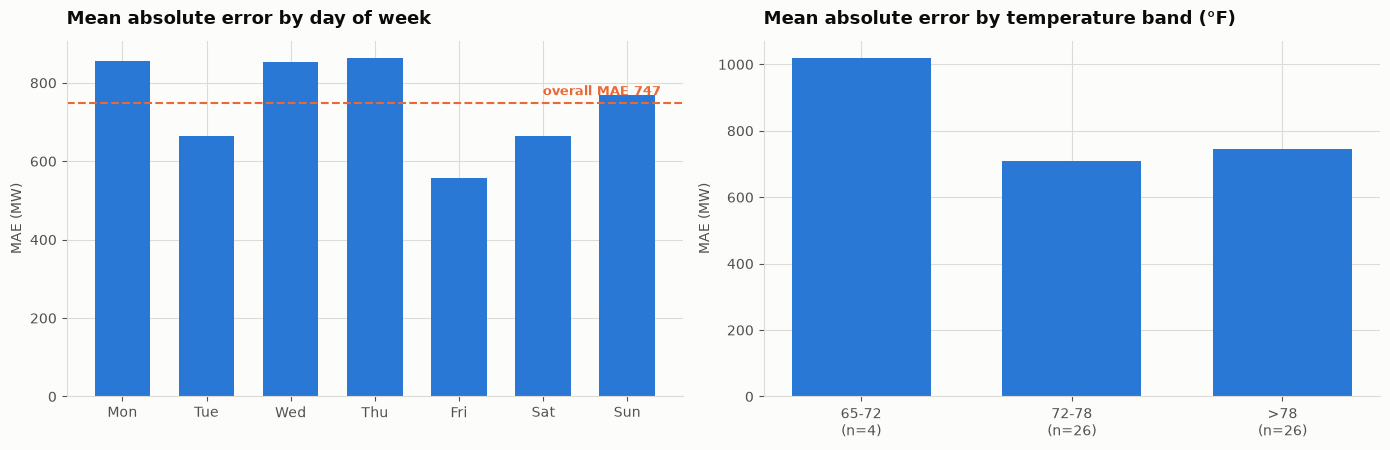

day_of_week
Mon    855.0
Tue    666.0
Wed    854.0
Thu    864.0
Fri    558.0
Sat    665.0
Sun    770.0

              mean  size
temp_avg_f              
65-72       1020.0     4
72-78        708.0    26
>78          745.0    26


In [39]:
# Where does the error concentrate? Two cuts: calendar and weather.
err = val_df.copy()
err["abs_error"] = np.abs(preds - err[TARGET_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# By day of week.
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = err.groupby("day_of_week")["abs_error"].mean().reindex(range(7))
axes[0].bar(range(7), by_dow.values, color=C["blue"], width=0.66)
axes[0].axhline(err["abs_error"].mean(), color=C["orange"], linestyle="--", linewidth=1.5)
axes[0].annotate(f"overall MAE {err['abs_error'].mean():,.0f}",
                 xy=(6.4, err["abs_error"].mean()), xytext=(0, 6),
                 textcoords="offset points", ha="right", fontsize=9,
                 color=C["orange"], weight="bold")
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(dow_names)
axes[0].set_title("Mean absolute error by day of week")
tidy(axes[0], ylabel="MAE (MW)")

# By temperature band.
temp_bins = pd.cut(err["temp_avg_f"], bins=[0, 55, 65, 72, 78, 120],
                   labels=["<55", "55-65", "65-72", "72-78", ">78"])
by_temp = err.groupby(temp_bins, observed=True)["abs_error"].agg(["mean", "size"])
axes[1].bar(range(len(by_temp)), by_temp["mean"].values, color=C["blue"], width=0.66)
axes[1].set_xticks(range(len(by_temp)))
axes[1].set_xticklabels([f"{i}\n(n={int(n)})" for i, n in zip(by_temp.index, by_temp["size"])])
axes[1].set_title("Mean absolute error by temperature band (\u00b0F)")
tidy(axes[1], ylabel="MAE (MW)")

plt.tight_layout()
plt.show()

print(by_dow.rename(index=dict(enumerate(dow_names))).round(0).to_string())
print()
print(by_temp.round(0).to_string())

## 8. Feature importance

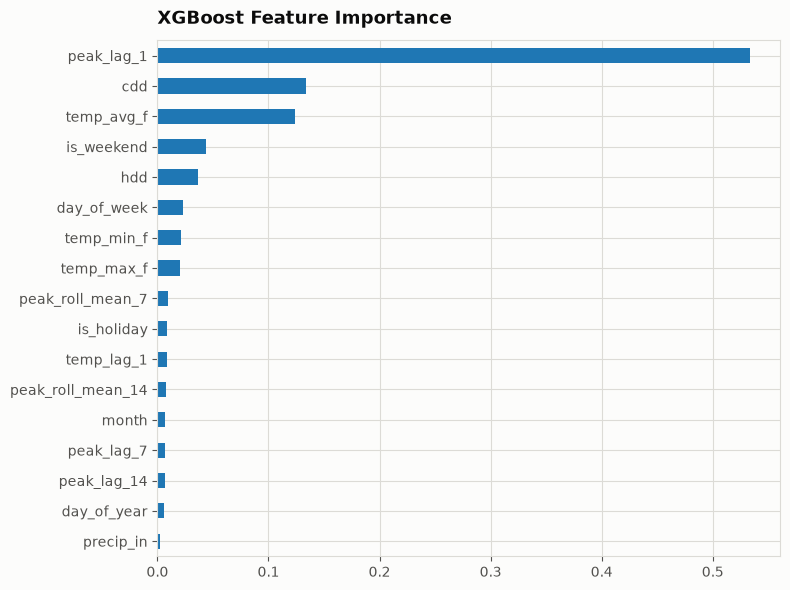

peak_lag_1           0.533841
cdd                  0.133334
temp_avg_f           0.123974
is_weekend           0.043881
hdd                  0.036909
day_of_week          0.022768
temp_min_f           0.020868
temp_max_f           0.020250
peak_roll_mean_7     0.009498
is_holiday           0.008846
temp_lag_1           0.008562
peak_roll_mean_14    0.007804
month                0.006974
peak_lag_7           0.006926
peak_lag_14          0.006785
day_of_year          0.006054
precip_in            0.002727
dtype: float32

In [40]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances.plot(kind="barh", title="XGBoost Feature Importance", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances


## 9. Save processed dataset

Persisting the merged/featured dataset locally so Phase 2 (SageMaker Processing Job) has a known-good reference to validate against, and so you're not re-hitting both APIs every time you iterate on the model.


In [41]:
import os
os.makedirs("data", exist_ok=True)
df_feat.to_csv("data/nyiso_daily_features.csv")
demand_weekly.to_csv("data/nyiso_weekly_demand.csv")
print("Saved data/nyiso_daily_features.csv and data/nyiso_weekly_demand.csv")


Saved data/nyiso_daily_features.csv and data/nyiso_weekly_demand.csv


## 10. Limitations

Stated plainly, because a forecast with unstated assumptions is a liability:

1. **This is a day-ahead model, not a general forecaster.** `peak_lag_1` assumes
   yesterday's actual peak is known. Horizons beyond one day need that feature
   removed and the whole thing re-scored - expect materially worse numbers.
2. **Validation is a single contiguous window**, so the score describes one
   season, not the year. A rolling-origin backtest across several folds would
   give an honest annual figure. The current split lands in cooling season.
3. **One weather station stands in for a state-wide system.** NYISO spans all of
   New York; LaGuardia is one point in the warmest, densest corner. Upstate
   heating load is effectively unmodelled.
4. **No behind-the-meter solar term.** Distributed PV suppresses measured demand
   and has grown materially since 2019, which puts a slow non-stationary trend
   in the target that none of these features can see.
5. **EIA demand figures are revised.** Recent days can move after publication, so
   the most recent rows are softer than the older ones.
6. **Timestamps are UTC, targets are aggregated on UTC days.** The EIA pull uses
   `frequency="hourly"` (UTC) and never localises, so a "day" here runs 19:00-19:00
   local in winter. The evening peak sits near that boundary, so a minority of days
   book their peak against the wrong calendar date. `frequency="local-hourly"` is
   the fix and should land before any of these numbers are quoted as operational.
7. **`weekly_total_mwh` is computed and saved but never modelled** - only half the
   stated target set is actually delivered here.

## Next steps (Phase 2+)

- [ ] Repeat sections 5-8 for the **weekly** target (`weekly_total_mwh`) — same feature approach, resampled to weekly grain
- [x] Wrap sections 1-4 into a standalone `preprocess.py` script → `scripts/nyiso_preprocess.py` (`make nyiso-data`)
- [x] Wrap sections 5-6 into a standalone `train.py` script → `scripts/nyiso_train.py` (`make nyiso-train`)
- [ ] Point MLflow tracking URI at a persistent server (not local `mlruns/`) once this moves off your laptop
- [ ] Register this first model in the MLflow / SageMaker Model Registry as the initial "champion" for future runs to beat

The two scripts reproduce this notebook exactly (MAE 731.9 MW, MAPE 3.11%) and
add a persistence baseline the notebook doesn't have — the model beats
"same as yesterday" by 38.7% on MAE, which is the number that says the result
is real rather than `peak_lag_1` wearing a hat.
